# Dimensionless Fall Velocity — Marconi Beach, Cape Cod

**Author:** Chelsea Volpano  
**Email:** cvolpano@contractor.usgs.gov | cvolpano@gmail.com  
**Date:** 2026-06-24  
**Created using Claude Sonnet 4.6**

---

Calculates the dimensionless fall velocity (Ω) using:
- Grain size data (D50 in µm) from sediment CSV
- Wave data (Hs, Tp) from NDBC 44020 and WIS ST63064

Settling velocity formulations from Soulsby (1997) as implemented in:  
https://github.com/csherwood-usgs/IPython_notebook_examples/blob/master/settling.ipynb
Dietrich (1982) as formulated in HEC-RAS 2D Sediment Transport
https://www.hec.usace.army.mil/confluence/rasdocs/d2sd/ras2dsedtr/

**Dimensionless fall velocity:**  
Ω = Hb / (ws * T)  
where Hb is breaker height, ws is settling velocity, T is wave period.

Beach state classification (Wright & Short 1984):  
- Ω < 1: Reflective  
- 1 ≤ Ω ≤ 6: Intermediate  
- Ω > 6: Dissipative

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

%matplotlib inline

In [14]:
# ── Configuration ─────────────────────────────────────────────────────────────
OUT_DIR      = Path("wave_data")
PLOT_DIR     = Path("wave_plots")
GRAIN_FILE   = OUT_DIR / "caco-waves_grainsize.csv"   # update path as needed
PLOT_DIR.mkdir(exist_ok=True)

# NDBC_FILE = OUT_DIR / "NDBC_44013_2006-01_to_2026-01.csv"
# WIS_FILE  = OUT_DIR / "WIS_ST63064_2006-01_to_2026-01.csv"

NDBC_FILE = OUT_DIR / "NDBC_44013_2024-10_to_2025-03.csv"
WIS_FILE  = OUT_DIR / "WIS_ST63064_2024-10_to_2024-12.csv"

# START = "2006-01-01"
# END = "2026-01-01"

START = "2024-10-01"
END   = "2025-03-31"

SURVEY_DATES = ["2024-10-23", "2025-01-23", "2025-03-06"]

# Physical constants
RHO_W   = 1025.0    # seawater density (kg/m³)
RHO_S   = 2650.0    # sediment density (kg/m³)
NU      = 1.36e-6   # kinematic viscosity of seawater at ~10°C (m²/s)
G       = 9.81      # gravitational acceleration (m/s²)

# Spectral colormap palette
_sp = plt.colormaps["plasma"]
PALETTE = {
    "ndbc":       _sp(0.08),
    "ndbc_mean": _sp(0.02),
    "wis":      _sp(0.95),
    "wis_mean":  _sp(0.99),
    "survey":    "black",
    "omega":     _sp(0.62),
}

## 1. Settling Velocity Formulations

From Soulsby (1997) *Dynamics of Marine Sands*, as in csherwood-usgs/IPython_notebook_examples.  


In [15]:
def settling_velocity(d_m, rho_s=RHO_S, rho_w=RHO_W, nu=NU, g=G, method="dietrich"):
    """
    Calculate settling velocity (m/s) for a grain of diameter d_m (metres).

    
    Methods:
    'soulsby'  — Soulsby (1997), valid for d = 0.063–2 mm
    'stokes'   — Stokes law (fine grains only, d < ~0.1 mm)
    'ferguson' — Ferguson & Church (2004)
    'dietrich' — Dietrich (1982), natural sediment


    Parameters
    ----------
    d_m   : float or array — grain diameter in metres
    rho_s : float — sediment density (kg/m³)
    rho_w : float — fluid density (kg/m³)
    nu    : float — kinematic viscosity (m²/s)
    g     : float — gravitational acceleration (m/s²)
    SF    : Corey (1949) shape factor 
    P     : Powers (1953) roundness index
    method: str   — 'soulsby', 'stokes', or 'ferguson'

    Returns
    -------
    ws : float or array — settling velocity (m/s)
    """
    s   = rho_s / rho_w          # relative density
    Dstar = d_m * ((s - 1) * g / nu**2)**(1/3)  # dimensionless grain size
    SF = 0.83    # Value from Sherwood settling.ipynb
    P  = 6      # Value from Sherwood settling.ipynb
    
    if method == "soulsby":
        # Soulsby (1997) Eq. 102
        ws = (nu / d_m) * (np.sqrt(10.36**2 + 1.049 * Dstar**3) - 10.36)

    elif method == "stokes":
        # Stokes law
        ws = (s - 1) * g * d_m**2 / (18 * nu)

    elif method == "ferguson":
        # Ferguson & Church (2004)
        C1, C2 = 18.0, 1.0
        ws = ((s - 1) * g * d_m**2) / (C1 * nu + (0.75 * C2 * (s - 1) * g * d_m**3)**0.5)

    elif method == "dietrich":
        R     = (s-1)          # submerged specific gravity
        Dstar = R * g * d_m**3 / nu**2           # dimensionless grain size (Different than others)
        logD  = np.log10(Dstar)

        R1 = (-3.76715
            + 1.92944 * logD
            - 0.09815 * logD**2
            - 0.00575 * logD**3
            + 0.00056 * logD**4)

        R2 = (np.log10(1.0 - (1 - SF) / 0.85)
            - (1.0 - SF)**2.3 * np.tanh(logD - 4.6)
            + 0.3 * (0.5 - SF) * (1.0 - SF)**2 * (logD - 4.6))

        R3 = (0.65 - (SF / 2.83) * np.tanh(logD - 4.6))**(1.0 + (3.5 - P) / 2.5)

        Wstar = R3 * 10**(R1 + R2)
        ws    = (Wstar * R * g * nu)**(1.0 / 3.0)
    else:
        raise ValueError(f"Unknown method '{method}'. Choose 'soulsby', 'stokes', 'dietrich' or 'ferguson'.")
    return ws



## 2. Load Grain Size Data

In [16]:
gs = pd.read_csv(GRAIN_FILE, encoding="latin1")  # latin1 handles µ symbol in headers

# Strip whitespace from column names
gs.columns = gs.columns.str.strip()

# Find D50 column — handles encoding variants of µm
d50_col = [c for c in gs.columns if "D50" in c and ("m" in c.lower() or "µ" in c or "Â" in c)]
if not d50_col:
    raise ValueError(f"Could not find D50 µm column. Available columns: {list(gs.columns)}")
d50_col = d50_col[0]
print(f"Using D50 column: '{d50_col}'")

gs["D50_m"]  = 2**(-pd.to_numeric(gs["D50_PHI"], errors="coerce")) / 1000  # phi → m
gs["ws_ms"]  = settling_velocity(gs["D50_m"], method="dietrich")
gs["ws_cms"] = gs["ws_ms"] * 100

print(f"D50 range: {gs['D50_m'].min()*1e6:.1f} – {gs['D50_m'].max()*1e6:.1f} µm")
print(f"ws range:  {gs['ws_cms'].min():.3f} – {gs['ws_cms'].max():.3f} cm/s")
# Parse sample date
date_col = [c for c in gs.columns if "DATE" in c.upper() and "COLLECTED" in c.upper()]

if date_col:
    gs["date"] = pd.to_datetime(gs[date_col[0]], errors="coerce")

print(f"\nLoaded {len(gs)} samples")
print(f"D50 range: {gs['D50_m'].min()*1e6:.1f} – {gs['D50_m'].max()*1e6:.1f} µm")
print(f"ws range:  {gs['ws_cms'].min():.3f} – {gs['ws_cms'].max():.3f} cm/s")
gs[["SAMPLE_ID", d50_col, "ws_cms"]].head()

Using D50 column: 'D50_Âµm'
D50 range: 238.2 – 702.2 µm
ws range:  2.149 – 8.750 cm/s

Loaded 6 samples
D50 range: 238.2 – 702.2 µm
ws range:  2.149 – 8.750 cm/s


,SAMPLE_ID,D50_Âµm,ws_cms
0,CACO-G1,727.42,8.749686
1,CACO-G1_dup,716.16,8.681540
2,CACO-G2,270.55,2.449533
3,CACO-G2_dup,253.87,2.148502
4,CACO-G3,667.42,8.150642


## 3. Load Wave Data

In [17]:
def load_ndbc(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "datetime"
    df = df[["WVHT", "DPD"]].rename(columns={"WVHT": "Hs", "DPD": "Tp"})
    df = df.apply(pd.to_numeric, errors="coerce")
    df["Hs"] = df["Hs"].where(df["Hs"] < 99.0)
    df["Tp"] = df["Tp"].where(df["Tp"] < 99.0)
    return df.resample("1h").mean()

def load_wis(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "datetime"
    df = df[["waveHs", "waveTp"]].rename(columns={"waveHs": "Hs", "waveTp": "Tp"})
    df = df.apply(pd.to_numeric, errors="coerce")
    return df

ndbc = load_ndbc(NDBC_FILE)
print(f"NDBC loaded: {len(ndbc)} rows")

if WIS_FILE.exists():
    wis = load_wis(WIS_FILE)
    print(f"WIS loaded:  {len(wis)} rows")
else:
    wis = None
    print("WIS file not found.")

NDBC loaded: 4368 rows
WIS loaded:  2205 rows


## 4. Calculate Dimensionless Fall Velocity (Ω)

Ω = Hs / (ws × Tp)  

Using offshore Hs and Tp directly as a proxy for breaker conditions.  
A separate ws is computed for each survey sample and applied to the wave record.

In [18]:
def compute_omega(wave_df, ws):
    """Compute Ω = Hs / (ws * Tp) and return as a Series."""
    return wave_df["Hs"] / (ws * wave_df["Tp"])

# ── Mean ws for summary stats ─────────────────────────────────────────────────
d50_mean = gs["D50_m"].mean()
ws_mean  = gs["ws_ms"].mean()
print(f"Mean D50: {d50_mean*1e6:.1f} µm")
print(f"Mean ws:  {ws_mean*100:.3f} cm/s")

# ── Compute omega time series using mean ws ───────────────────────────────────
ndbc_omega = compute_omega(ndbc, ws_mean)
if wis is not None:
    wis_omega = compute_omega(wis, ws_mean)

# ── Beach state summary ───────────────────────────────────────────────────────
print(f"\nNDBC 44020 Ω — mean={ndbc_omega.mean():.2f}  "
      f"median={ndbc_omega.median():.2f}  "
      f"max={ndbc_omega.max():.2f}")
print(f"  Reflective   (Ω < 1):  {(ndbc_omega < 1).mean()*100:.1f}%")
print(f"  Intermediate (1≤Ω≤6): {((ndbc_omega >= 1) & (ndbc_omega <= 6)).mean()*100:.1f}%")
print(f"  Dissipative  (Ω > 6):  {(ndbc_omega > 6).mean()*100:.1f}%")

Mean D50: 522.1 µm
Mean ws:  6.185 cm/s

NDBC 44020 Ω — mean=2.93  median=3.00  max=7.25
  Reflective   (Ω < 1):  11.0%
  Intermediate (1≤Ω≤6): 86.7%
  Dissipative  (Ω > 6):  1.1%


## 5. Per-Sample Ω at Survey Dates

For each sediment sample, compute ws and look up the wave conditions at the nearest survey date.

In [19]:
results = []
for _, row in gs.iterrows():
    if pd.isna(row["ws_ms"]):
        continue
    ws = row["ws_ms"]

    # Find nearest survey date
    sample_date = row.get("date", pd.NaT)
    if pd.isna(sample_date):
        survey_date = pd.Timestamp(SURVEY_DATES[0])
    else:
        survey_date = min(SURVEY_DATES, key=lambda d: abs(pd.Timestamp(d) - sample_date))
        survey_date = pd.Timestamp(survey_date)

    # Get wave conditions within ±12 hours of survey date from raw ndbc
    window = ndbc.loc[
        (ndbc.index >= survey_date - pd.Timedelta(hours=12)) &
        (ndbc.index <= survey_date + pd.Timedelta(hours=12))
    ]
    if window.empty:
        continue

    Hs_survey = window["Hs"].mean()
    Tp_survey = window["Tp"].mean()
    omega     = Hs_survey / (ws * Tp_survey)

    results.append({
        "SAMPLE_ID":   row["SAMPLE_ID"],
        "D50_um":      row["D50_m"] * 1e6,
        "ws_cms":      ws * 100,
        "survey_date": survey_date,
        "Hs_m":        Hs_survey,
        "Tp_s":        Tp_survey,
        "omega":       omega,
    })

results_df = pd.DataFrame(results)
print(results_df[["SAMPLE_ID", "D50_um", "ws_cms", "survey_date", "Hs_m", "Tp_s", "omega"]].to_string(index=False))

  SAMPLE_ID     D50_um   ws_cms survey_date   Hs_m   Tp_s    omega
    CACO-G1 702.222438 8.749686  2025-01-23 0.5948 6.7234 1.011089
CACO-G1_dup 697.371833 8.681540  2025-01-23 0.5948 6.7234 1.019026
    CACO-G2 260.616440 2.449533  2025-01-23 0.5948 6.7234 3.611592
CACO-G2_dup 238.159500 2.148502  2025-01-23 0.5948 6.7234 4.117620
    CACO-G3 659.753955 8.150642  2025-01-23 0.5948 6.7234 1.085401
CACO-G3_dup 574.349177 6.931355  2025-01-23 0.5948 6.7234 1.276333


## 6. Plots

In [20]:
def style_xaxis(ax, start, end):
    span_days = (pd.Timestamp(end) - pd.Timestamp(start)).days
    if span_days <= 180:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    elif span_days <= 730:
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    else:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0)


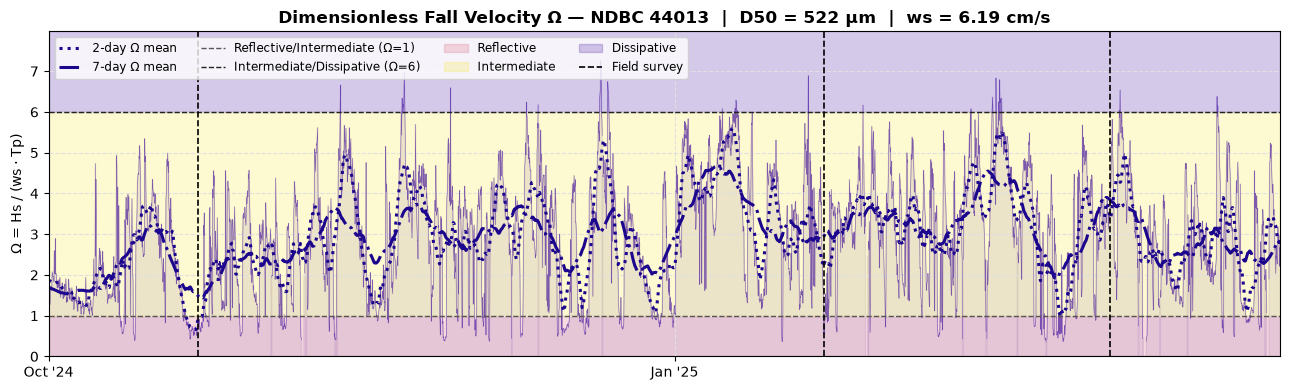

✓ Saved omega_timeseries_2024-10-01-2025-03-31.png


In [21]:
# ── Figure 1: Ω time series for mean grainsize samples ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

ax.fill_between(ndbc_omega.index, ndbc_omega, alpha=0.1, color=PALETTE["ndbc"])
ax.plot(ndbc_omega.index, ndbc_omega, color=PALETTE["ndbc"], lw=0.4, alpha=0.6)

ax.plot(ndbc_omega.index,
        ndbc_omega.rolling("2D", center=True, min_periods=24).mean(),
        color=PALETTE["ndbc_mean"], ls=":", lw=2.2, label="2-day Ω mean")

ax.plot(ndbc_omega.index,
        ndbc_omega.rolling("7D", center=True, min_periods=24).mean(),
        color=PALETTE["ndbc_mean"], ls="-.", lw=2.2, label="7-day Ω mean")

# Beach state threshold lines
ax.axhline(1, color="#555", lw=1.0, ls="--", label="Reflective/Intermediate (Ω=1)")
ax.axhline(6, color="#222", lw=1.0, ls="--", label="Intermediate/Dissipative (Ω=6)")

# Shade beach state regions
ymax = ndbc_omega.max() * 1.1
ax.axhspan(0, 1,    alpha=0.21, color=_sp(0.55), label="Reflective")
ax.axhspan(1, 6,    alpha=0.21, color=_sp(0.95), label="Intermediate")
ax.axhspan(6, ymax, alpha=0.21, color=_sp(0.08), label="Dissipative")

# Survey lines
for i, d in enumerate(SURVEY_DATES):
    ax.axvline(pd.Timestamp(d), color=PALETTE["survey"], lw=1.2, ls="--",
               label="Field survey" if i == 0 else "_nolegend_")

ax.set_ylabel("Ω = Hs / (ws · Tp)")
ax.set_title(f"Dimensionless Fall Velocity Ω — NDBC 44013  |  D50 = {d50_mean*1e6:.0f} µm  |  ws = {ws_mean*100:.2f} cm/s",
             fontweight="bold")
ax.set_xlim(pd.Timestamp(START), pd.Timestamp(END))
ax.set_ylim(0, ymax)
ax.legend(loc="upper left", ncol=4, fontsize=8.5)
ax.grid(color="#e0e0e0", linewidth=0.8, linestyle="--")
style_xaxis(ax, START, END)

fig.tight_layout()
fig.savefig(PLOT_DIR / f"omega_timeseries_{START}-{END}.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"✓ Saved omega_timeseries_{START}-{END}.png")

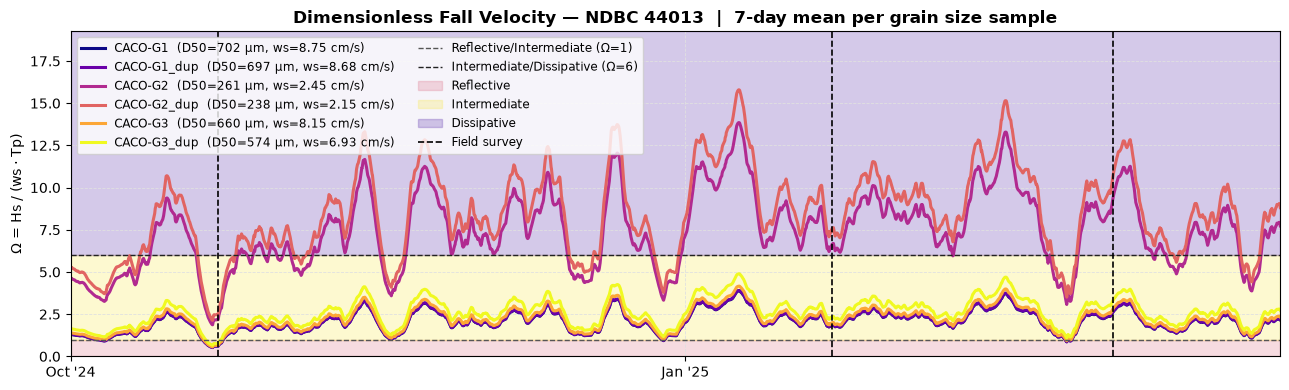

✓ Saved omega_timeseries_per_sample.png


In [27]:
# ── Figure 2: Ω time series for all grain size samples ───────────────────────────────────────────────────
# # Use a spectral colormap to colour each sample's line
n_samples     = len(gs)
sample_colors = [_sp(i / max(n_samples - 1, 1)) for i in range(n_samples)]

# ── Figure: Ω time series per grain size sample ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

for (_, row), color in zip(gs.iterrows(), sample_colors):
    ws      = row["ws_ms"]
    label   = row["SAMPLE_ID"]
    d50_um  = row["D50_m"] * 1e6
    omega   = compute_omega(ndbc, ws)
    omega_r = omega.rolling("3D", center=True, min_periods=24).mean()

    
    
    ax.plot(omega.index, omega_r, color=color, lw=2.2,
            label=f"{label}  (D50={d50_um:.0f} µm, ws={ws*100:.2f} cm/s)")

# Beach state threshold lines
ax.axhline(1, color="#555", lw=1.0, ls="--", label="Reflective/Intermediate (Ω=1)")
ax.axhline(6, color="#222", lw=1.0, ls="--", label="Intermediate/Dissipative (Ω=6)")

# Beach state shading — use 99th percentile of coarsest grain (lowest ws = highest Ω)
ymax = max(
    compute_omega(ndbc, row["ws_ms"]).quantile(0.99)
    for _, row in gs.iterrows()
) * 1.1
ax.axhspan(0, 1,    alpha=0.21, color=_sp(0.55), label="Reflective")
ax.axhspan(1, 6,    alpha=0.21, color=_sp(0.95), label="Intermediate")
ax.axhspan(6, ymax, alpha=0.21, color=_sp(0.08), label="Dissipative")

# Survey lines
for i, d in enumerate(SURVEY_DATES):
    ax.axvline(pd.Timestamp(d), color=PALETTE["survey"], lw=1.2, ls="--",
               label="Field survey" if i == 0 else "_nolegend_")

ax.set_ylabel("Ω = Hs / (ws · Tp)")
ax.set_title("Dimensionless Fall Velocity — NDBC 44013  |  7-day mean per grain size sample",
             fontweight="bold")
ax.set_xlim(pd.Timestamp(START), pd.Timestamp(END))
ax.set_ylim(0, ymax)
style_xaxis(ax, START, END)
ax.legend(loc="upper left", ncol=2, fontsize=8.5)
ax.grid(color="#e0e0e0", linewidth=0.6, linestyle="--")

fig.tight_layout()
fig.savefig(PLOT_DIR / "omega_timeseries_per_sample.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved omega_timeseries_per_sample.png")

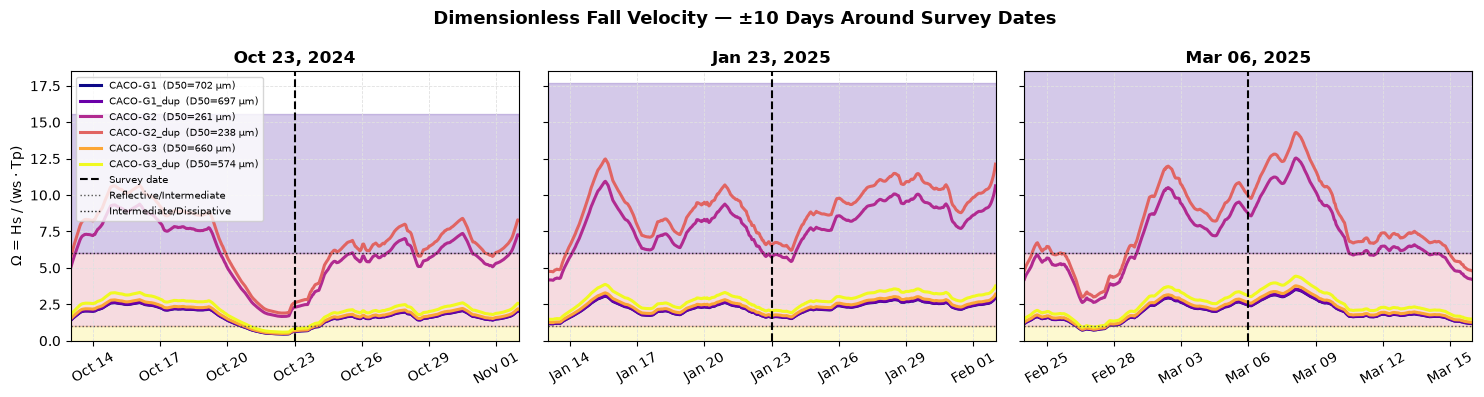

✓ Saved omega_survey_windows.png


In [31]:
# ── Figure 3: Ω centered on survey dates ±7 days ───────────────────────────────
WINDOW_DAYS = 10  # days either side of survey date
ROLLING_WINDOW = "2D"
n_surveys = len(SURVEY_DATES)
fig, axes = plt.subplots(1, n_surveys, figsize=(5 * n_surveys, 4), sharey=True)
fig.suptitle(f"Dimensionless Fall Velocity — ±{WINDOW_DAYS} Days Around Survey Dates",
             fontsize=13, fontweight="bold")

for ax, survey_date in zip(axes, SURVEY_DATES):
    t0 = pd.Timestamp(survey_date) - pd.Timedelta(days=WINDOW_DAYS)
    t1 = pd.Timestamp(survey_date) + pd.Timedelta(days=WINDOW_DAYS)

    for (_, row), color in zip(gs.iterrows(), sample_colors):
        ws      = row["ws_ms"]
        label   = row["SAMPLE_ID"]
        d50_um  = row["D50_m"] * 1e6
        omega   = compute_omega(ndbc, ws).loc[t0:t1]
        omega_r = omega.rolling(ROLLING_WINDOW, center=True, min_periods=6).mean()

        if omega.empty:
            continue

        
        ax.plot(omega.index, omega_r, color=color, lw=2.2,
                label=f"{label}  (D50={d50_um:.0f} µm)")

    # Survey date line
    ax.axvline(pd.Timestamp(survey_date), color=PALETTE["survey"],
               lw=1.5, ls="--", label="Survey date")

    # Beach state thresholds
    ax.axhline(1, color="#555", lw=1.0, ls=":", label="Reflective/Intermediate")
    ax.axhline(6, color="#222", lw=1.0, ls=":", label="Intermediate/Dissipative")

    # Beach state shading
    ymax = max(
        compute_omega(ndbc, row["ws_ms"]).loc[t0:t1].quantile(0.99)
        for _, row in gs.iterrows()
        if not compute_omega(ndbc, row["ws_ms"]).loc[t0:t1].empty
    ) * 1.1
    ax.axhspan(0, 1,    alpha=0.21, color=_sp(0.95))
    ax.axhspan(1, 6,    alpha=0.21, color=_sp(0.55))
    ax.axhspan(6, ymax, alpha=0.21, color=_sp(0.08))

    ax.set_title(pd.Timestamp(survey_date).strftime("%b %d, %Y"), fontweight="bold")
    ax.set_xlim(t0, t1)
    ax.set_ylim(0, ymax)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(color="#e0e0e0", linewidth=0.6, linestyle="--")

    if ax == axes[0]:
        ax.set_ylabel("Ω = Hs / (ws · Tp)")
        ax.legend(loc="upper left", fontsize=7.5, ncol=1)

fig.tight_layout()
fig.savefig(PLOT_DIR / "omega_survey_windows.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved omega_survey_windows.png")

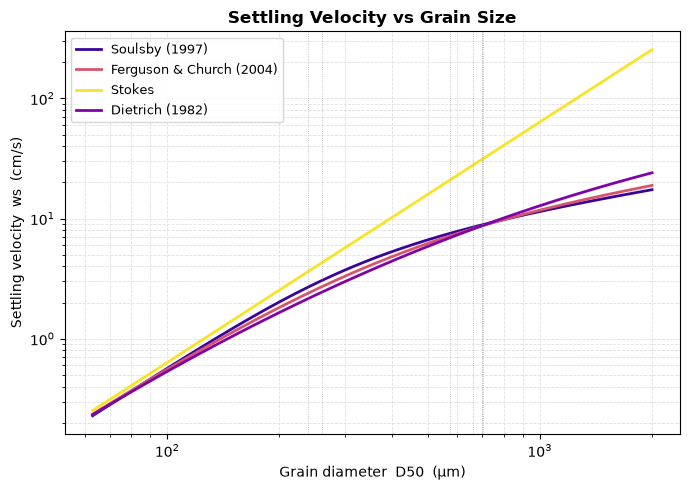

✓ Saved settling_velocity.png


In [32]:
# ── Figure 4: ws vs D50 for all formulations ──────────────────────────────────
d_range = np.logspace(np.log10(63e-6), np.log10(2000e-6), 200)  # 63 µm – 2 mm

fig2, ax2 = plt.subplots(figsize=(7, 5))
for method, color, label in [
    ("soulsby",  _sp(0.08), "Soulsby (1997)"),
    ("ferguson", _sp(0.55), "Ferguson & Church (2004)"),
    ("stokes",   _sp(0.95), "Stokes"),
    ("dietrich", _sp(0.25),"Dietrich (1982)")
]:
    ws_range = settling_velocity(d_range, method=method) * 100  # cm/s
    ax2.plot(d_range * 1e6, ws_range, lw=2, label=label,
             color=color)

# Mark sample D50s
for _, row in gs.iterrows():
    if not pd.isna(row["D50_m"]):
        ax2.axvline(row["D50_m"] * 1e6, color="grey", lw=0.6, ls=":", alpha=0.6)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Grain diameter  D50  (µm)")
ax2.set_ylabel("Settling velocity  ws  (cm/s)")
ax2.set_title("Settling Velocity vs Grain Size", fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(color="#e0e0e0", linewidth=0.6, linestyle="--", which="both")

fig2.tight_layout()
fig2.savefig(PLOT_DIR / "settling_velocity.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved settling_velocity.png")

In [34]:
# ── Save results ──────────────────────────────────────────────────────────────
OUT_DIR = "wave_data"
out_path =  f"dimensionless_fall_velocity{START}-{END}.csv"
results_df.to_csv(out_path, index=False)
print(f"✓ Saved per-sample results → {out_path}")

# Save omega time series — join ndbc Hs/Tp with omega Series
omega_out = f"omega_timeserie{START}-{END}.csv"

pd.concat([ndbc[["Hs", "Tp"]], ndbc_omega.rename("omega")], axis=1).to_csv(omega_out)
print(f"✓ Saved Ω time series → {omega_out}")

✓ Saved per-sample results → dimensionless_fall_velocity2024-10-01-2025-03-31.csv
✓ Saved Ω time series → omega_timeserie2024-10-01-2025-03-31.csv


In [ ]:
# ## Sanity Check
# d_test = 250e-6
# s      = 2650 / 1025
# nu     = 1.36e-6
# g      = 9.81
# Dstar  = d_test * ((s - 1) * g / nu**2)**(1/3)
# print(f"d_test: {d_test:.6f} m")
# # Quick sanity check — 250 µm sand
d_m   = 250e-6
rho_s = 2650.0
rho_w = 1025.0
nu    = 1.36e-6
g     = 9.81
SF    = 0.83
P     = 6

R     = (rho_s - rho_w) / rho_w
Dstar = R * g * d_m**3 / nu**2
logD  = np.log10(Dstar)

R1 = (-3.76715 + 1.92944*logD - 0.09815*logD**2 - 0.00575*logD**3 + 0.00056*logD**4)
R2 = (np.log10(1.0 - SF/0.85) - (1.0-SF)**2.3 * np.tanh(logD-4.6) + 0.3*(0.5-SF)*(1.0-SF)**2*(logD-4.6))
R3 = (0.65 - (SF/2.83)*np.tanh(logD-4.6))**(1.0+(3.5-P)/2.5)

Wstar = R3 * 10**(R1+R2)
ws    = (Wstar * R * g * nu)**(1.0/3.0)

print(f"R:      {R:.4f}")
print(f"Dstar:  {Dstar:.4f}")
print(f"logD:   {logD:.4f}")
print(f"R1:     {R1:.4f}")
print(f"R2:     {R2:.4f}")
print(f"R3:     {R3:.4f}")
print(f"Wstar:  {Wstar:.6f}")
print(f"ws:     {ws*100:.4f} cm/s")

print(f"gs['D50_m'].mean():  {gs['D50_m'].mean():.6f}")
print(f"d50_mean:            {d50_mean:.6f}")
print(f"ws_mean:             {ws_mean:.6f} m/s = {ws_mean*100:.4f} cm/s")
print(f"settling_velocity(d50_mean): {settling_velocity(d50_mean)*100:.4f} cm/s")
print(f"settling_velocity(gs['D50_m'].mean()): {settling_velocity(gs['D50_m'].mean())*100:.4f} cm/s")

print(f"gs['ws_ms'].mean():  {gs['ws_ms'].mean():.6f} m/s")